# MDC calculation — Cohorts A and B

Calculate MDC estimates for the two cohorts.

All analyses are computed for each cohort and target separately.

In [14]:
import pandas as pd
import numpy as np
import sklearn.metrics as sk_metrics
from scipy.stats import pearsonr
from scipy import stats
import matplotlib.pyplot as plt
import pingouin as pg
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import chi2 as chi2_dist
from semopy import Model, calc_stats

from datetime import datetime
now = lambda: datetime.now().strftime("%Y-%m-%d %H:%M")

In [15]:
VERSION = 'kw19_withoutCohortB'

n_bootsrap_samples = 10000

# Cohort definitions: (label, wave_a, wave_b)
COHORTS = [
    ('A', 'wave1', 'wave2'),
    ('B', 'wave2', 'wave3'),
]

target = 'language'

results = {'A': {}, 'B': {}}

## Load longitudinal data for both cohorts

In [16]:
def load_longitudinal(version, cohort_label):
    path = f"transformed_data/{version}_predictions_targets_longitudinal_cohort{cohort_label}.csv"
    return pd.read_csv(path, header=[0, 1, 2], index_col=0)


longitudinal_by_cohort = {
    label: load_longitudinal(VERSION, label) for label, _, _ in COHORTS
}

for label, wave_a, wave_b in COHORTS:
    print(f'Cohort {label} ({wave_a} ↔ {wave_b}): shape = {longitudinal_by_cohort[label].shape}')
    results[label]['n'] = longitudinal_by_cohort[label].shape[0]

Cohort A (wave1 ↔ wave2): shape = (305, 40)
Cohort B (wave2 ↔ wave3): shape = (70, 40)


## Test-retest reliability (ICC) of targets and predictions

In [17]:
def calculate_test_retest(longitudinal, target, wave_a, wave_b):
    test_retest_data_long = pd.DataFrame({
        'score': pd.concat((
            longitudinal[(wave_a, target, 'target')],
            longitudinal[(wave_b, target, 'target')],
        ), axis=0, ignore_index=True),
        'time': pd.concat((
            pd.Series(wave_a, index=longitudinal.index),
            pd.Series(wave_b, index=longitudinal.index),
        ), axis=0, ignore_index=True),
        'participant': pd.concat((
            pd.Series(longitudinal.index),
            pd.Series(longitudinal.index),
        ), axis=0, ignore_index=True),
    })
    icc_result = pg.intraclass_corr(
        data=test_retest_data_long, targets='participant', raters='time',
        ratings='score', nan_policy='omit',
    )
    icc_31 = icc_result.loc[icc_result['Type'] == 'ICC3', 'ICC'].values[0]
    return icc_31


def calculate_test_retest_predictions(longitudinal, target, task, wave_a, wave_b):
    test_retest_data_long = pd.DataFrame({
        'score': pd.concat((
            longitudinal[(wave_a, target, task)],
            longitudinal[(wave_b, target, task)],
        ), axis=0, ignore_index=True),
        'time': pd.concat((
            pd.Series(wave_a, index=longitudinal.index),
            pd.Series(wave_b, index=longitudinal.index),
        ), axis=0, ignore_index=True),
        'participant': pd.concat((
            pd.Series(longitudinal.index),
            pd.Series(longitudinal.index),
        ), axis=0, ignore_index=True),
    })
    icc_result = pg.intraclass_corr(
        data=test_retest_data_long, targets='participant', raters='time',
        ratings='score', nan_policy='omit',
    )
    icc_31 = icc_result.loc[icc_result['Type'] == 'ICC3', 'ICC'].values[0]
    return icc_31


for label, wave_a, wave_b in COHORTS:
    r = calculate_test_retest(longitudinal_by_cohort[label], target, wave_a, wave_b)
    print(f'Cohort {label} ({wave_a} ↔ {wave_b}) — ICC31 ({target}): {r:.2f}')
    results[label][f'ICC_{target}'] = r

Cohort A (wave1 ↔ wave2) — ICC31 (language): 0.69
Cohort B (wave2 ↔ wave3) — ICC31 (language): 0.72


## Add average-prediction columns per cohort

In [18]:
def get_col(task, wave, target):
    return (wave, target, task)


tasks = ['cookieTheft', 'picnicScene', 'journaling']
all_targets = ['language', 'executive_function', 'speed', 'memory']


def add_average_predictions(longitudinal, wave_a, wave_b, tasks, all_targets):
    """Add per-wave avg_speech_prediction and avg_cookieTheft_picnicScene
    columns to a longitudinal frame, for every target available in the frame."""
    longitudinal = longitudinal.copy()
    for wave in [wave_a, wave_b]:
        for target_here in all_targets:
            # Only act if columns exist for this target/wave combo
            available_tasks = [
                t for t in tasks if (wave, target_here, t) in longitudinal.columns
            ]
            if not available_tasks:
                continue
            task_cols = [(wave, target_here, t) for t in available_tasks]
            longitudinal[(wave, target_here, 'avg_speech_prediction')] = (
                longitudinal[task_cols].mean(axis=1)
            )
            pic_tasks = [
                t for t in ['picnicScene', 'cookieTheft']
                if (wave, target_here, t) in longitudinal.columns
            ]
            if pic_tasks:
                pic_cols = [(wave, target_here, t) for t in pic_tasks]
                longitudinal[(wave, target_here, 'avg_cookieTheft_picnicScene')] = (
                    longitudinal[pic_cols].mean(axis=1)
                )
    return longitudinal.sort_index(axis=1, level=[0, 1, 2])


for label, wave_a, wave_b in COHORTS:
    longitudinal_by_cohort[label] = add_average_predictions(
        longitudinal_by_cohort[label], wave_a, wave_b, tasks, all_targets,
    )

longitudinal_by_cohort['A'].head()

wave1                        \
                                  executive_function                         
                         avg_cookieTheft_picnicScene avg_speech_prediction   
sample_name_longitudinal                                                     
01d1fdfc3a                                  0.158273              0.106112   
0367083668                                  0.700962              0.555722   
048eb2a01e                                  0.826348              0.936988   
049af4901b                                 -0.265565             -0.185160   
04d9f72ef8                                 -0.203391             -0.101870   

                                                                              \
                                                                               
                         cookieTheft journaling picnicScene    target   wave   
sample_name_longitudinal                                                       
01d1fdfc3a                  0.138795   0.001790    0.177751 -0.805223  wave1   
0367083668                  0.772846   0.265243    0.629078  1.371604  wave1   
048eb2a01e                  0.749054   1.158267    0.903641  1.068259  wave1   
049af4901b                 -0.128629  -0.024350   -0.402501  0.399128  wave1   
04d9f72ef8                 -0.119317   0.101174   -0.287465 -0.074194  wave1   

                                                                            \
                                            language                         
                         avg_cookieTheft_picnicScene avg_speech_prediction   
sample_name_longitudinal                                                     
01d1fdfc3a                                  0.027702              0.055753   
0367083668                                  0.460353              0.290175   
048eb2a01e                                  0.865098              1.007436   
049af4901b                                 -0.467820             -0.366378   
04d9f72ef8                                 -0.165733             -0.267911   

                                      ...       wave2                   \
                                      ...      memory                    
                         cookieTheft  ... picnicScene    target   wave   
sample_name_longitudinal              ...                                
01d1fdfc3a                 -0.110649  ...    0.461068 -2.676297  wave2   
0367083668                  0.527400  ...    0.370298 -0.328401  wave2   
048eb2a01e                  0.686082  ...    0.379806  1.167577  wave2   
049af4901b                 -0.421994  ...   -0.286512 -0.283585  wave2   
04d9f72ef8                 -0.060667  ...    0.153035 -0.662634  wave2   

                                                                            \
                                               speed                         
                         avg_cookieTheft_picnicScene avg_speech_prediction   
sample_name_longitudinal                                                     
01d1fdfc3a                                 -0.004444              0.012161   
0367083668                                  0.507666              0.500362   
048eb2a01e                                  0.153483              0.164649   
049af4901b                                 -0.096972              0.006734   
04d9f72ef8                                  0.088824              0.173802   

                                                                              
                                                                              
                         cookieTheft journaling picnicScene    target   wave  
sample_name_longitudinal                                                      
01d1fdfc3a                 -0.081001   0.045371    0.072113 -2.152385  wave2  
0367083668                  0.396828   0.485754    0.618505  1.470132  wave2  
048eb2a01e                  0.044612   0.186979    0.262354  0.262024  wave2

In [19]:
for label, wave_a, wave_b in COHORTS:
    print(f'\n=== Cohort {label} ({wave_a} ↔ {wave_b}) ===')
    long_df = longitudinal_by_cohort[label]
    for task in ['cookieTheft', 'picnicScene', 'journaling',
                 'avg_speech_prediction', 'avg_cookieTheft_picnicScene']:
        r_here = calculate_test_retest_predictions(long_df, target, task, wave_a, wave_b)
        print(f'  ICC31 ({target}) {task}: {r_here:.3f}')
        results[label][f'ICC_{target}_{task}'] = r_here


=== Cohort A (wave1 ↔ wave2) ===
  ICC31 (language) cookieTheft: 0.650
  ICC31 (language) picnicScene: 0.755
  ICC31 (language) journaling: 0.568
  ICC31 (language) avg_speech_prediction: 0.801
  ICC31 (language) avg_cookieTheft_picnicScene: 0.795

=== Cohort B (wave2 ↔ wave3) ===
  ICC31 (language) cookieTheft: 0.753
  ICC31 (language) picnicScene: 0.839
  ICC31 (language) journaling: 0.736
  ICC31 (language) avg_speech_prediction: 0.887
  ICC31 (language) avg_cookieTheft_picnicScene: 0.876


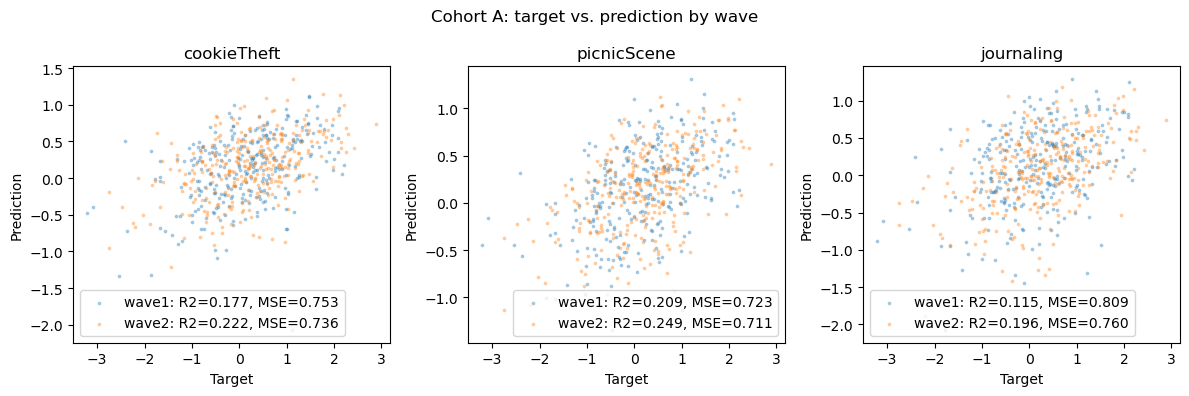

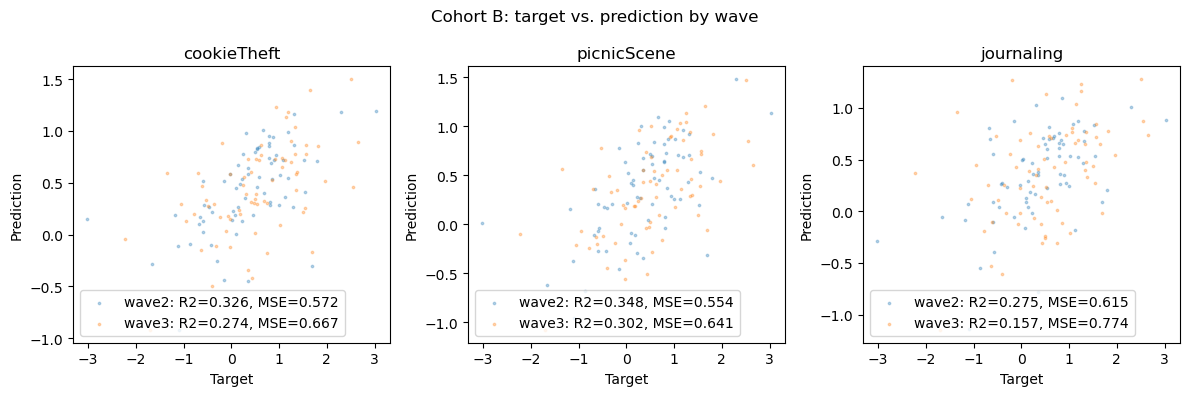

In [20]:
def plot_target_vs_prediction_scatter(longitudinal, label, wave_a, wave_b):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for task, ax in zip(['cookieTheft', 'picnicScene', 'journaling'], axes):
        for wave in [wave_a, wave_b]:
            data_here = longitudinal[
                [(wave, target, 'target'), (wave, target, task)]
            ].copy().dropna()
            r2 = r2_score(
                data_here[(wave, target, 'target')],
                data_here[(wave, target, task)],
            )
            mse = mean_squared_error(
                data_here[(wave, target, 'target')],
                data_here[(wave, target, task)],
            )
            ax.scatter(
                data_here[(wave, target, 'target')],
                data_here[(wave, target, task)],
                alpha=0.3,
                label=f"{wave}: R2={r2:.3f}, MSE={mse:.3f}",
                s=3,
            )
        ax.set_title(task)
        ax.legend()
        ax.set_xlabel('Target')
        ax.set_ylabel('Prediction')
    fig.suptitle(f'Cohort {label}: target vs. prediction by wave')
    plt.tight_layout()
    plt.show()


for label, wave_a, wave_b in COHORTS:
    plot_target_vs_prediction_scatter(longitudinal_by_cohort[label], label, wave_a, wave_b)

## MDC calculation with bootstrap CIs

In [21]:
import pingouin as pg


def _icc31(a, b) -> float:
    """
    ICC(3,1) via pingouin, mirroring calculate_test_retest's long-format setup.
    `a` and `b` are paired vectors (e.g. wave_a and wave_b ratings).
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n = len(a)
    if n < 2:
        return np.nan
    long_df = pd.DataFrame({
        "score": np.concatenate([a, b]),
        "time": np.concatenate([np.full(n, "a"), np.full(n, "b")]),
        "participant": np.concatenate([np.arange(n), np.arange(n)]),
    })
    try:
        icc_result = pg.intraclass_corr(
            data=long_df, targets="participant", raters="time",
            ratings="score", nan_policy="omit",
        )
        return icc_result.loc[icc_result["Type"] == "ICC3", "ICC"].values[0]
    except Exception:
        return np.nan


def _icc31(a: np.ndarray, b: np.ndarray) -> float:
    """
    ICC(3,1): two-way mixed, single rater, consistency.
    Computed from one-way-within-subjects ANOVA with k=2 ratings per subject.
        ICC(3,1) = (MS_between - MS_within) / (MS_between + (k-1) * MS_within)
    Returns np.nan if degenerate.
    Much faster than pg version above
    Checked if the two agree in analyses/kw20/test_icc_pg_vs_custom.ipynb
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]
    n = len(a)
    if n < 2:
        return np.nan
    k = 2
    subj_means = (a + b) / 2.0
    grand_mean = (a.sum() + b.sum()) / (2 * n)
    ss_between = k * np.sum((subj_means - grand_mean) ** 2)
    ss_within = np.sum((a - subj_means) ** 2) + np.sum((b - subj_means) ** 2)
    ms_between = ss_between / (n - 1)
    ms_within = ss_within / (n * (k - 1))
    denom = ms_between + (k - 1) * ms_within
    if not np.isfinite(denom) or denom <= 0:
        return np.nan
    return (ms_between - ms_within) / denom


def calculate_mdc_with_bootstrap_CI(
    df: pd.DataFrame,
    domain: str = "language",
    tasks=("cookieTheft", "picnicScene", "journaling",
           "avg_speech_prediction", "avg_cookieTheft_picnicScene"),
    waves=("wave1", "wave2"),
    z: float = 1.96,
    n_boot: int = 2000,
    ci: float = 0.95,
    random_state: int | None = 0,
) -> pd.DataFrame:
    """
    Estimate MDC with nonparametric bootstrap CIs.
    """
    wave_a, wave_b = waves
    alpha = (1 - ci) / 2
    rng = np.random.default_rng(random_state)

    x1 = df[(wave_a, domain, "target")]
    x2 = df[(wave_b, domain, "target")]
    target_pair = pd.concat({"x1": x1, "x2": x2}, axis=1).dropna()
    if len(target_pair) < 3:
        raise ValueError("Not enough complete target pairs.")

    # Build per-task complete-case frames once
    task_frames = {}
    for task in tasks:
        y1 = df[(wave_a, domain, task)]
        y2 = df[(wave_b, domain, task)]
        tmp = pd.concat({"x1": x1, "x2": x2, "y1": y1, "y2": y2}, axis=1).dropna()
        if len(tmp) < 3:
            raise ValueError(f"Not enough complete cases for task {task!r}.")
        task_frames[task] = tmp

    # Point estimates
    var_c_hat = target_pair["x1"].cov(target_pair["x2"])
    reliability_target = target_pair["x1"].corr(target_pair["x2"])
    var_y_obs = np.mean([target_pair["x1"].var(), target_pair["x2"].var()])
    if not np.isfinite(var_c_hat) or var_c_hat <= 0:
        raise ValueError(f"Var(C) non-positive ({var_c_hat:.4f}).")
    mdc_cognitive = z * np.sqrt(2 * var_y_obs * (1 - reliability_target))
    icc_cognitive_hat = _icc31(target_pair["x1"].values, target_pair["x2"].values)

    rows = []
    for task, tmp in task_frames.items():
        n = len(tmp)
        regression_r2 = np.mean([
            sk_metrics.r2_score(tmp["x1"], tmp["y1"]),
            sk_metrics.r2_score(tmp["x2"], tmp["y2"]),
        ])
        regression_mse = np.mean([
            sk_metrics.mean_squared_error(tmp["x1"], tmp["y1"]),
            sk_metrics.mean_squared_error(tmp["x2"], tmp["y2"]),
        ])
        cov_y1_x1 = tmp["y1"].cov(tmp["x1"])
        cov_y2_x2 = tmp["y2"].cov(tmp["x2"])
        lambda_hat = np.mean([cov_y1_x1, cov_y2_x2]) / var_c_hat

        delta_yhat = tmp["y2"] - tmp["y1"]
        var_delta_yhat = delta_yhat.var()
        sd_delta_yhat = delta_yhat.std()
        sigma_epsilon_sq_hat = var_delta_yhat / 2.0
        mdc_speech_pred = z * sd_delta_yhat
        mdc_speech_latent = mdc_speech_pred / np.abs(lambda_hat)

        icc_hat = _icc31(tmp["y1"].values, tmp["y2"].values)

        rows.append({
            "task": task, "n": n,
            "regression_r2": regression_r2,
            "regression_mse": regression_mse,
            "var_c_hat": var_c_hat,
            "var_y_obs": var_y_obs,
            "target_reliability_hat": reliability_target,
            "lambda_hat": lambda_hat,
            "var_delta_yhat": var_delta_yhat,
            "sd_delta_yhat": sd_delta_yhat,
            "sigma_epsilon_sq_hat": sigma_epsilon_sq_hat,
            "sigma_epsilon_hat": np.sqrt(sigma_epsilon_sq_hat),
            "mdc_speech_pred": mdc_speech_pred,
            "mdc_speech_latent": mdc_speech_latent,
            "mdc_cognitive": mdc_cognitive,
            "icc_hat": icc_hat,
            "icc_cognitive_hat": icc_cognitive_hat,
        })

    # --- Bootstrap ---
    boot_speech_pred   = {t: np.empty(n_boot) for t in tasks}
    boot_speech_latent = {t: np.empty(n_boot) for t in tasks}
    boot_cognitive     = {t: np.empty(n_boot) for t in ['all'] + list(tasks)}
    boot_r2            = {t: np.empty(n_boot) for t in tasks}
    boot_icc           = {t: np.empty(n_boot) for t in tasks}
    boot_icc_cognitive = np.empty(n_boot)
    n_target = len(target_pair)

    task_n = {t: len(f) for t, f in task_frames.items()}

    for b in range(n_boot):
        #if b % (n_boot // 10) == 0:
        #    print(f"Bootstrap {b+1}/{n_boot}...", end="", flush=True)

        # Cognitive MDC and ICC on a resample of the full target pair
        idx_t = rng.integers(0, n_target, n_target)
        tp_b = target_pair.iloc[idx_t]
        var_c_b = tp_b["x1"].cov(tp_b["x2"])
        rel_b = tp_b["x1"].corr(tp_b["x2"])
        var_y_b = np.mean([tp_b["x1"].var(), tp_b["x2"].var()])
        if np.isfinite(var_c_b) and var_c_b > 0 and np.isfinite(rel_b):
            boot_cognitive['all'][b] = z * np.sqrt(2 * var_y_b * max(1 - rel_b, 0))
        else:
            boot_cognitive['all'][b] = np.nan
        boot_icc_cognitive[b] = _icc31(tp_b["x1"].values, tp_b["x2"].values)

        for task, frame in task_frames.items():
            nn = task_n[task]
            idx = rng.integers(0, nn, nn)
            tb = frame.iloc[idx]

            vc  = tb["x1"].cov(tb["x2"])
            rel = tb["x1"].corr(tb["x2"])
            var_y_b = np.mean([tb["x1"].var(), tb["x2"].var()])

            if np.isfinite(vc) and vc > 0 and np.isfinite(rel):
                boot_cognitive[task][b] = z * np.sqrt(2 * var_y_b * max(1 - rel, 0))
            else:
                boot_cognitive[task][b] = np.nan

            # R^2 per wave averaged on the bootstrap sample
            try:
                r2_b = np.mean([
                    sk_metrics.r2_score(tb["x1"], tb["y1"]),
                    sk_metrics.r2_score(tb["x2"], tb["y2"]),
                ])
            except Exception:
                r2_b = np.nan
            boot_r2[task][b] = r2_b

            # ICC(3,1) on the speech predictions
            boot_icc[task][b] = _icc31(tb["y1"].values, tb["y2"].values)

            if not np.isfinite(vc) or vc <= 0:
                boot_speech_pred[task][b] = np.nan
                boot_speech_latent[task][b] = np.nan
                continue
            lam = np.mean([tb["y1"].cov(tb["x1"]), tb["y2"].cov(tb["x2"])]) / vc
            sd_d = (tb["y2"] - tb["y1"]).std()
            mp = z * sd_d
            boot_speech_pred[task][b] = mp
            boot_speech_latent[task][b] = (
                mp / np.abs(lam) if np.isfinite(lam) and not np.isclose(lam, 0) else np.nan
            )

    lo_q, hi_q = alpha, 1 - alpha

    icc_cog_lo, icc_cog_hi = np.nanpercentile(boot_icc_cognitive, [100 * lo_q, 100 * hi_q])

    for row in rows:
        t = row["task"]
        speech_pred_here = boot_speech_pred[t]
        speech_latent_here = boot_speech_latent[t]
        cognitive = boot_cognitive[t]
        r2 = boot_r2[t]
        icc = boot_icc[t]

        mdc_speech_pred_low, mdc_speech_pred_high = np.nanpercentile(speech_pred_here, [100*lo_q, 100*hi_q])
        row["mdc_speech_pred_text"] = (
            f"{row['mdc_speech_pred']:.2f} "
            f"({mdc_speech_pred_low:.2f}-{mdc_speech_pred_high:.2f})"
        )

        mdc_speech_latent_low, mdc_speech_latent_high = np.nanpercentile(speech_latent_here, [100*lo_q, 100*hi_q])
        row["mdc_speech_latent_text"] = (
            f"{row['mdc_speech_latent']:.2f} "
            f"({mdc_speech_latent_low:.2f}-{mdc_speech_latent_high:.2f})"
        )

        mdc_cognitive_low, mdc_cognitive_high = np.nanpercentile(cognitive, [100*lo_q, 100*hi_q])
        row["mdc_cognitive_text"] = (
            f"{row['mdc_cognitive']:.2f} "
            f"({mdc_cognitive_low:.2f}-{mdc_cognitive_high:.2f})"
        )

        r2_low, r2_high = np.nanpercentile(r2, [100*lo_q, 100*hi_q])
        row["regression_r2_text"] = (
            f"{row['regression_r2']:.2f} ({r2_low:.2f}-{r2_high:.2f})"
        )

        icc_low, icc_high = np.nanpercentile(icc, [100*lo_q, 100*hi_q])
        row["icc_text"] = (
            f"{row['icc_hat']:.2f} ({icc_low:.2f}-{icc_high:.2f})"
        )

        row["icc_cognitive_text"] = (
            f"{row['icc_cognitive_hat']:.2f} ({icc_cog_lo:.2f}-{icc_cog_hi:.2f})"
        )

        row['mdc_speech_latent_bootstrap_dist'] = speech_latent_here
        row['mdc_cognition_bootstrap_dist_task'] = cognitive
        row['mdc_speech_pred_bootstrap_dist'] = speech_pred_here
        row['mdc_cognition_bootstrap_dist_all'] = boot_cognitive['all']


    return pd.DataFrame(rows).set_index("task")



mdc_results_by_cohort = {}
for label, wave_a, wave_b in COHORTS:
    print(f'\n=== Cohort {label} ({wave_a} ↔ {wave_b}) — running bootstrap ===')
    mdc_results_by_cohort[label] = calculate_mdc_with_bootstrap_CI(
        longitudinal_by_cohort[label], domain=target,
        waves=(wave_a, wave_b), n_boot=n_bootsrap_samples,
    )
    results[label]['mdc'] = mdc_results_by_cohort[label]

mdc_results_by_cohort['A']


=== Cohort A (wave1 ↔ wave2) — running bootstrap ===

=== Cohort B (wave2 ↔ wave3) — running bootstrap ===


,n,regression_r2,regression_mse,var_c_hat,var_y_obs,target_reliability_hat,lambda_hat,var_delta_yhat,sd_delta_yhat,sigma_epsilon_sq_hat,...,mdc_speech_pred_text,mdc_speech_latent_text,mdc_cognitive_text,regression_r2_text,icc_text,icc_cognitive_text,mdc_speech_latent_bootstrap_dist,mdc_cognition_bootstrap_dist_task,mdc_speech_pred_bootstrap_dist,mdc_cognition_bootstrap_dist_all
task,,,,,,,,,,,,,,,,,,,,,
cookieTheft,294,0.192224,0.730808,0.622586,0.907575,0.686059,0.300861,0.139643,0.373689,0.069822,...,0.73 (0.66-0.82),2.43 (1.93-3.13),1.48 (1.29-1.67),0.19 (0.10-0.26),0.65 (0.58-0.71),0.69 (0.60-0.75),"[2.18852241748522, 2.850221055381878, 3.266915...","[1.4593407270183594, 1.476923993272189, 1.3300...","[0.6774967417836314, 0.7595581572610582, 0.811...","[1.476593202354407, 1.5130501306068374, 1.5006..."
picnicScene,294,0.226218,0.700084,0.622586,0.907575,0.686059,0.335170,0.103042,0.321002,0.051521,...,0.63 (0.58-0.68),1.88 (1.53-2.32),1.48 (1.29-1.66),0.23 (0.15-0.29),0.76 (0.70-0.80),0.69 (0.60-0.75),"[1.6131309481019467, 1.7027399067938933, 1.749...","[1.504058292365643, 1.3533362538059734, 1.5769...","[0.613287376311582, 0.6011175665803687, 0.6317...","[1.476593202354407, 1.5130501306068374, 1.5006..."
journaling,294,0.146454,0.772361,0.622586,0.907575,0.686059,0.327964,0.229533,0.479096,0.114766,...,0.94 (0.84-1.03),2.86 (2.27-3.66),1.48 (1.29-1.67),0.15 (0.05-0.23),0.57 (0.49-0.63),0.69 (0.60-0.75),"[3.2289533380855633, 3.2959405864525935, 2.811...","[1.5022091194771319, 1.3909972986082428, 1.487...","[0.9512368996434036, 0.9400480017612336, 0.895...","[1.476593202354407, 1.5130501306068374, 1.5006..."
avg_speech_prediction,294,0.245179,0.682957,0.622586,0.907575,0.686059,0.321332,0.069387,0.263414,0.034693,...,0.52 (0.47-0.56),1.61 (1.32-1.96),1.48 (1.29-1.67),0.25 (0.17-0.30),0.80 (0.76-0.84),0.69 (0.60-0.75),"[1.625416038836376, 1.5633595618915455, 1.5736...","[1.4791158369474307, 1.4785196035548798, 1.540...","[0.549722121710855, 0.5040136620857001, 0.4822...","[1.476593202354407, 1.5130501306068374, 1.5006..."
avg_cookieTheft_picnicScene,294,0.238449,0.689019,0.622586,0.907575,0.686059,0.318015,0.072968,0.270126,0.036484,...,0.53 (0.48-0.57),1.66 (1.36-2.06),1.48 (1.29-1.67),0.24 (0.16-0.30),0.80 (0.75-0.83),0.69 (0.60-0.75),"[1.5439892191876716, 1.9837648132291672, 1.696...","[1.6365550105330553, 1.4512129316040348, 1.354...","[0.5020383169492049, 0.56252340112307, 0.49239...","[1.476593202354407, 1.5130501306068374, 1.5006..."


In [22]:
mdc_results_by_cohort['B']

,n,regression_r2,regression_mse,var_c_hat,var_y_obs,target_reliability_hat,lambda_hat,var_delta_yhat,sd_delta_yhat,sigma_epsilon_sq_hat,...,mdc_speech_pred_text,mdc_speech_latent_text,mdc_cognitive_text,regression_r2_text,icc_text,icc_cognitive_text,mdc_speech_latent_bootstrap_dist,mdc_cognition_bootstrap_dist_task,mdc_speech_pred_bootstrap_dist,mdc_cognition_bootstrap_dist_all
task,,,,,,,,,,,,,,,,,,,,,
cookieTheft,70,0.300040,0.619416,0.6438,0.89645,0.718712,0.359074,0.092758,0.304562,0.046379,...,0.60 (0.46-0.72),1.66 (1.14-2.38),1.39 (1.03-1.70),0.30 (0.13-0.42),0.76 (0.61-0.86),0.71 (0.58-0.81),"[1.5255457880349608, 1.5013579366980447, 1.537...","[1.3554972095286417, 1.2905822579061603, 1.417...","[0.6317858027674418, 0.5357318323164567, 0.606...","[1.0392114210952743, 1.5508148656314658, 1.544..."
picnicScene,70,0.324761,0.597466,0.6438,0.89645,0.718712,0.419913,0.075464,0.274707,0.037732,...,0.54 (0.45-0.62),1.28 (0.91-1.81),1.39 (1.04-1.69),0.32 (0.13-0.46),0.84 (0.75-0.90),0.71 (0.58-0.81),"[1.2447778164211454, 1.3928230922401388, 1.256...","[1.2552527670489, 1.434549432605965, 1.1205781...","[0.5599814008276534, 0.5126963875692135, 0.562...","[1.0392114210952743, 1.5508148656314658, 1.544..."
journaling,70,0.216070,0.694756,0.6438,0.89645,0.718712,0.315799,0.107367,0.327669,0.053683,...,0.64 (0.51-0.76),2.03 (1.30-3.46),1.39 (1.03-1.69),0.22 (0.02-0.35),0.74 (0.57-0.85),0.71 (0.58-0.81),"[1.8636352115779293, 2.385780747022791, 1.8499...","[1.1557951881920923, 1.5888704073696855, 1.462...","[0.613144552748684, 0.6982003768482982, 0.6015...","[1.0392114210952743, 1.5508148656314658, 1.544..."
avg_speech_prediction,70,0.319319,0.602579,0.6438,0.89645,0.718712,0.364929,0.039538,0.198842,0.019769,...,0.39 (0.32-0.46),1.07 (0.73-1.52),1.39 (1.03-1.71),0.32 (0.16-0.44),0.89 (0.82-0.93),0.71 (0.58-0.81),"[0.9335940045880025, 1.147413522619089, 0.9598...","[1.3408324018689468, 1.5265795359139225, 1.573...","[0.3494666924148533, 0.3712335371321517, 0.400...","[1.0392114210952743, 1.5508148656314658, 1.544..."
avg_cookieTheft_picnicScene,70,0.334239,0.588957,0.6438,0.89645,0.718712,0.389494,0.047711,0.218429,0.023856,...,0.43 (0.34-0.50),1.10 (0.75-1.55),1.39 (1.03-1.70),0.33 (0.17-0.46),0.88 (0.81-0.93),0.71 (0.58-0.81),"[1.0846514900828526, 1.2065400582167825, 1.373...","[1.344309674641989, 1.3036439445126364, 1.4825...","[0.4184072921038892, 0.47956358231371765, 0.44...","[1.0392114210952743, 1.5508148656314658, 1.544..."


## Bootstrap test: speech MDC − cognitive MDC

In [23]:
def bootstrap_diff_speech_minus_cognitive_significance_test(
    results: pd.DataFrame, ci: float = 0.95,
) -> pd.DataFrame:
    alpha = (1 - ci) / 2
    out = []
    for task, row in results.iterrows():
        speech = np.asarray(row["mdc_speech_latent_bootstrap_dist"], dtype=float)
        cogn = np.asarray(row["mdc_cognition_bootstrap_dist_task"], dtype=float)
        mask = np.isfinite(speech) & np.isfinite(cogn)
        d = speech[mask] - cogn[mask]
        lo, hi = np.nanpercentile(d, [100*alpha, 100*(1-alpha)])
        out.append({
            "task": task,
            "n_pairs": len(d),
            "mean_diff": d.mean(),
            "median_diff": np.median(d),
            "ci_low": lo,
            "ci_high": hi,
            "prop_speech_worse": np.mean(d > 0),
            "excludes_zero": lo > 0 or hi < 0,
        })
    return pd.DataFrame(out).set_index("task")


bootstrap_test_by_cohort = {}
for label, _, _ in COHORTS:
    bootstrap_test_by_cohort[label] = bootstrap_diff_speech_minus_cognitive_significance_test(
        mdc_results_by_cohort[label]
    )
    print(f'\n=== Cohort {label} ===')
    display(bootstrap_test_by_cohort[label])
    results[label]['bootstrap_test'] = bootstrap_test_by_cohort[label]


=== Cohort A ===


,n_pairs,mean_diff,median_diff,ci_low,ci_high,prop_speech_worse,excludes_zero
task,,,,,,,
cookieTheft,10000,0.974285,0.951891,0.366040,1.726183,0.9996,True
picnicScene,10000,0.412286,0.402674,-0.061082,0.940559,0.9541,False
journaling,10000,1.402275,1.378176,0.687866,2.270126,1.0000,True
avg_speech_prediction,10000,0.139654,0.134418,-0.279725,0.589247,0.7362,False
avg_cookieTheft_picnicScene,10000,0.199488,0.187419,-0.230098,0.684495,0.8078,False



=== Cohort B ===


,n_pairs,mean_diff,median_diff,ci_low,ci_high,prop_speech_worse,excludes_zero
task,,,,,,,
cookieTheft,10000,0.316095,0.287596,-0.289539,1.061708,0.8185,False
picnicScene,10000,-0.061830,-0.079456,-0.554518,0.510974,0.3899,False
journaling,10000,0.745726,0.660269,-0.143285,2.159772,0.9391,False
avg_speech_prediction,10000,-0.280315,-0.291002,-0.746901,0.243022,0.1290,False
avg_cookieTheft_picnicScene,10000,-0.253096,-0.263693,-0.707943,0.258047,0.1454,False


## Forest plot — one PDF per cohort

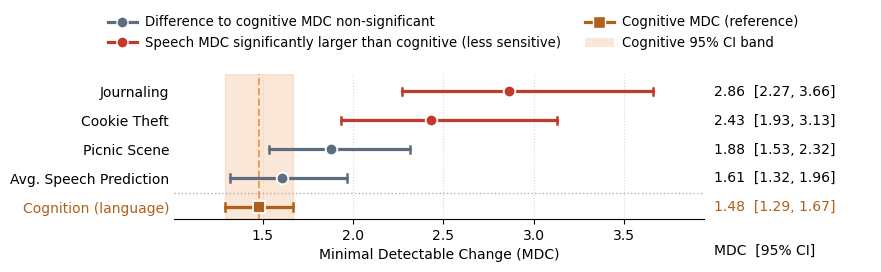

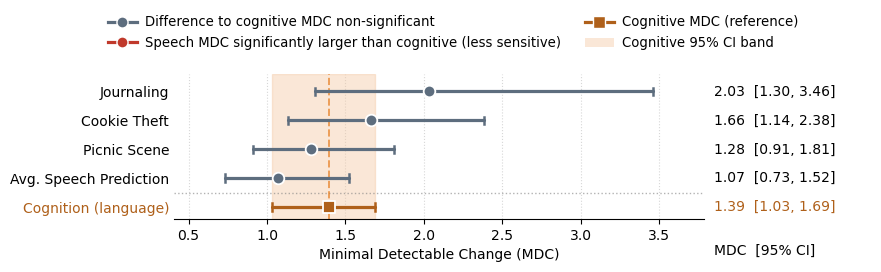

In [24]:
task_replacement = {
    'journaling': 'Journaling',
    'cookieTheft': 'Cookie Theft',
    'picnicScene': 'Picnic Scene',
    'avg_speech_prediction': 'Avg. Speech Prediction',
}


def ci(dist, alpha=0.05):
    lo, hi = np.percentile(dist, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return lo, hi


def classify_by_ci(speech_lo, speech_hi, cog_lo, cog_hi):
    """Compare a speech CI to the cognitive CI band."""
    if speech_hi < cog_lo:
        return "better"
    if speech_lo > cog_hi:
        return "worse"
    return "overlap"


def make_classifier(bootstrap_test_res):
    """Closure over a cohort-specific bootstrap test dataframe."""
    def classify(task):
        if bootstrap_test_res.loc[task, 'excludes_zero']:
            return 'worse'
        else:
            return 'overlap'
    return classify


def forest_plot(df, classify_fn, title_suffix='', figsize=None, xlim=None):
    tasks = df.index.tolist()
    n = len(tasks)

    speech_vals = df["mdc_speech_latent"].values.astype(float)
    speech_ci = np.array([ci(d) for d in df["mdc_speech_latent_bootstrap_dist"]])

    cog_val = float(df["mdc_cognitive"].iloc[0])
    cog_lo, cog_hi = ci(df["mdc_cognition_bootstrap_dist_all"].iloc[0])

    # Sort speech tasks so smallest MDC ends up closest to the cognition row.
    order = np.argsort(speech_vals)[::-1]
    tasks = [tasks[i] for i in order]
    tasks_renamed = [task_replacement.get(t, t) for t in tasks]
    speech_vals = speech_vals[order]
    speech_ci = speech_ci[order]

    C = {
        "better":   "#1E8449",
        "overlap":  "#5D6D7E",
        "worse":    "#C0392B",
        "cog":      "#E67E22",
        "cog_dark": "#AF601A",
        "cog_band": "#F5CBA7",
    }

    if figsize is None:
        figsize = (11, max(4.5, 0.6 * (n + 1) + 3.0))
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        2, 2,
        width_ratios=[3.3, 1.0],
        height_ratios=[0.15, 1],
        hspace=0.5, wspace=0.02,
        figure=fig,
    )
    ax = fig.add_subplot(gs[1, 0])
    ax_tbl = fig.add_subplot(gs[1, 1], sharey=ax)
    ax_leg = fig.add_subplot(gs[0, :])
    ax_leg.axis("off")

    # Rows 0..n-1 = speech tasks (top). Row n = cognition (bottom).
    y_speech = np.arange(n)
    y_cog = n

    # Reference band + line for cognitive CI (spans full plot).
    ax.axvspan(cog_lo, cog_hi, color=C["cog_band"], alpha=0.45, zorder=1)
    ax.axvline(cog_val, color=C["cog"], linestyle="--", linewidth=1.4,
               alpha=0.7, zorder=2)

    # Separator between speech tasks and cognition reference row.
    ax.axhline(n - 0.5, color="gray", linestyle=":", linewidth=1, alpha=0.6,
               zorder=1)

    # Speech CIs + point estimates
    for yi, val, (lo, hi), task in zip(y_speech, speech_vals, speech_ci, tasks):
        color = C[classify_fn(task)]
        ax.plot([lo, hi], [yi, yi], color=color, linewidth=2.3,
                solid_capstyle="round", zorder=3)
        ax.plot([lo, lo], [yi - 0.13, yi + 0.13], color=color, linewidth=1.8, zorder=3)
        ax.plot([hi, hi], [yi - 0.13, yi + 0.13], color=color, linewidth=1.8, zorder=3)
        ax.scatter([val], [yi], s=70, color=color,
                   edgecolor="white", linewidth=1.3, zorder=4)

    # Cognition row — square marker in orange to distinguish from speech circles
    ax.plot([cog_lo, cog_hi], [y_cog, y_cog], color=C["cog_dark"],
            linewidth=2.3, solid_capstyle="round", zorder=3)
    ax.plot([cog_lo, cog_lo], [y_cog - 0.13, y_cog + 0.13],
            color=C["cog_dark"], linewidth=1.8, zorder=3)
    ax.plot([cog_hi, cog_hi], [y_cog - 0.13, y_cog + 0.13],
            color=C["cog_dark"], linewidth=1.8, zorder=3)
    ax.scatter([cog_val], [y_cog], s=70, color=C["cog_dark"], marker="s",
               edgecolor="white", linewidth=1.3, zorder=4)

    # Y-axis: task labels + cognition label
    ax.set_yticks(list(y_speech) + [y_cog])
    ax.set_yticklabels(tasks_renamed + [f"Cognition ({target})"])
    yticklabels = ax.get_yticklabels()
    yticklabels[-1].set_color(C["cog_dark"])

    ax.set_ylim(-0.6, n + 0.4)
    ax.invert_yaxis()

    if xlim is None:
        all_lo = min(speech_ci[:, 0].min(), cog_lo)
        all_hi = max(speech_ci[:, 1].max(), cog_hi)
        pad = 0.12 * (all_hi - all_lo)
        xlim = (max(0, all_lo - pad), all_hi + pad)
    ax.set_xlim(*xlim)
    ax.set_xlabel("Minimal Detectable Change (MDC)")
    if title_suffix:
        ax.set_title(title_suffix, loc='left', fontsize=10)

    ax.grid(axis="x", linestyle=":", alpha=0.5)
    ax.set_axisbelow(True)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="y", length=0)

    # Numeric column
    ax_tbl.set_xlim(0, 1)
    ax_tbl.set_ylim(ax.get_ylim())
    ax_tbl.axis("off")
    ax_tbl.text(0.02, y_cog + 1.5, "MDC  [95% CI]",
                fontsize=10, fontweight="normal", va="center", ha="left")
    for yi, val, (lo, hi) in zip(y_speech, speech_vals, speech_ci):
        ax_tbl.text(0.02, yi, f"{val:.2f}  [{lo:.2f}, {hi:.2f}]",
                    fontsize=10, va="center", ha="left")
    ax_tbl.text(0.02, y_cog,
                f"{cog_val:.2f}  [{cog_lo:.2f}, {cog_hi:.2f}]",
                fontsize=10, va="center", ha="left",
                fontweight="normal", color=C["cog_dark"])

    # Legend strip on top
    legend_elements = [
        Line2D([0], [0], marker="o", color=C["overlap"], lw=2.3, markersize=8,
               markeredgecolor="white",
               label="Difference to cognitive MDC non-significant"),
        Line2D([0], [0], marker="o", color=C["worse"], lw=2.3, markersize=8,
               markeredgecolor="white",
               label="Speech MDC significantly larger than cognitive (less sensitive)"),
        Line2D([0], [0], marker="s", color=C["cog_dark"], lw=2.3, markersize=8,
               markeredgecolor="white",
               label="Cognitive MDC (reference)"),
        Patch(facecolor=C["cog_band"], alpha=0.45, label="Cognitive 95% CI band"),
    ]
    ax_leg.legend(
        handles=legend_elements, frameon=False, fontsize=9.5,
        loc="center",
        bbox_to_anchor=[0.4, 0],
        ncol=2,
        handlelength=2.2, columnspacing=1.8, handletextpad=0.6,
    )

    return fig, ax


for label, wave_a, wave_b in COHORTS:
    classify_fn = make_classifier(bootstrap_test_by_cohort[label])
    df_for_plot = mdc_results_by_cohort[label].query(
        "task != 'avg_cookieTheft_picnicScene'"
    )
    fig, ax = forest_plot(
        df_for_plot, classify_fn,
        #title_suffix=f'Cohort {label}: {wave_a} ↔ {wave_b}',
        figsize=(9, 2.7),
    )
    plt.savefig(f"plots/MDC_{target}_{VERSION}_cohort{label}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

## Bootstrap test — LaTeX tables (one per cohort)

In [25]:
for label, wave_a, wave_b in COHORTS:
    bootstrap_test_res = bootstrap_test_by_cohort[label]
    bootstrap_test_beautified = bootstrap_test_res.copy().loc[
        ~bootstrap_test_res.index.str.startswith("avg_cookieTheft_picnicScene")
    ].copy()
    bootstrap_test_beautified['ci'] = bootstrap_test_beautified.apply(
        lambda row: f"{row['ci_low']:.2f} -- {row['ci_high']:.2f}", axis=1,
    )
    bootstrap_test_beautified['prop_speech_worse'] = bootstrap_test_beautified['prop_speech_worse'].apply(lambda frac: f"{frac:.1%}")
    bootstrap_test_beautified = bootstrap_test_beautified[
        ['mean_diff', 'ci', 'prop_speech_worse', 'excludes_zero']
    ].rename(
        columns={
            'mean_diff': 'Mean Diff',
            'ci_low': '95% CI Low',
            'ci_high': '95% CI High',
            'ci': '95% CI',
            'prop_speech_worse': '\\shortstack[l]{% Speech\\\\MDC larger}',
            'excludes_zero': '\\shortstack[l]{Significant\\\\difference}',
        },
        index={t: task_replacement.get(t, t) for t in bootstrap_test_beautified.index},
    )
    bootstrap_test_beautified.index.name = None

    bootstrap_test_rest_latex = bootstrap_test_beautified.to_latex(
        float_format="%.2f",
        column_format="lcccccc",
        label=f"tab:mdc_bootstrap_test_rest_cohort{label}",
        caption=(
            f"Bootstrap test results assessing if the speech-based MDC is significantly larger than cognitive MDC on Cohort {label}. We report the mean difference in MDCs across {n_bootsrap_samples} bootstrap replicates, the 95% CI of the difference, and the proportion of replicates where speech MDC is larger (worse) than cognitive MDC."
        ),
    ).replace("%", "\\%")
    print(f'\n% === MDC stats results: Cohort {label} ({now()}) ===')
    print(bootstrap_test_rest_latex)


% === MDC stats results: Cohort A (2026-07-24 12:09) ===
\begin{table}
\caption{Bootstrap test results assessing if the speech-based MDC is significantly larger than cognitive MDC on Cohort A. We report the mean difference in MDCs across 10000 bootstrap replicates, the 95\% CI of the difference, and the proportion of replicates where speech MDC is larger (worse) than cognitive MDC.}
\label{tab:mdc_bootstrap_test_rest_cohortA}
\begin{tabular}{lcccccc}
\toprule
 & Mean Diff & 95\% CI & \shortstack[l]{\% Speech\\MDC larger} & \shortstack[l]{Significant\\difference} \\
\midrule
Cookie Theft & 0.97 & 0.37 -- 1.73 & 100.0\% & True \\
Picnic Scene & 0.41 & -0.06 -- 0.94 & 95.4\% & False \\
Journaling & 1.40 & 0.69 -- 2.27 & 100.0\% & True \\
Avg. Speech Prediction & 0.14 & -0.28 -- 0.59 & 73.6\% & False \\
\bottomrule
\end{tabular}
\end{table}


% === MDC stats results: Cohort B (2026-07-24 12:09) ===
\begin{table}
\caption{Bootstrap test results assessing if the speech-based MDC is signific

## SEM — four-indicator measurement model

In [26]:
sem_tasks = ['cookieTheft', 'picnicScene', 'journaling']

def fit_four_indicator_sem(dat, model_type="full"):
    """
    Fit one of seven measurement models to four indicators per participant
    (y1, y2, hat_y1, hat_y2).

    Baseline ("full") assumes:
      - time-invariant attenuation lam on hat_y,
      - stable speaker bias b, orthogonal to C, with unit loadings on hat_y,
      - stationary residual variances (v1 for y, ve for hat_y),
      - independent residuals across waves.
    """
    specs = {
        "full": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            b =~ 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
            b ~~ b
            c ~~ 0*b
        """,
        "no_attenuation": """
            c =~ 1*y1 + 1*y2 + 1*hat_y1 + 1*hat_y2
            b =~ 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
            b ~~ b
            c ~~ 0*b
        """,
        "no_beta": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
        """,
        "no_attenuation_no_beta": """
            c =~ 1*y1 + 1*y2 + 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
        """,
        "correlated_hat_residuals": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            hat_y1 ~~ rh*hat_y2
            c ~~ c
        """,
        "free_hat_resid_by_wave": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            b =~ 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve1*hat_y1
            hat_y2 ~~ ve2*hat_y2
            c ~~ c
            b ~~ b
            c ~~ 0*b
        """,
        "free_y_resid_by_wave": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            b =~ 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v2*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
            b ~~ b
            c ~~ 0*b
        """,
    }

    if model_type not in specs:
        raise ValueError(f"Unknown model_type: {model_type}")

    sem_desc = specs[model_type]
    try:
        model = Model(sem_desc, mimic_lavaan=True)
        model.fit(dat)
        fit_stats = calc_stats(model)

        # manual srmr calculation, checked against R's lavaan implementation
        obs_vars = model.vars['observed']
        S = dat[obs_vars].cov().values
        n = dat.shape[0]
        S = S * (n - 1) / n  # match lavaan's ML sample cov
        Sigma, _ = model.calc_sigma()
        inv_std = np.diag(1 / np.sqrt(np.diag(S)))
        S_std = inv_std @ S @ inv_std
        Sigma_std = inv_std @ Sigma @ inv_std
        R = S_std - Sigma_std
        idx = np.tril_indices_from(R)
        residuals = R[idx]
        srmr = np.sqrt(np.mean(residuals**2))
        fit_stats["SRMR"] = srmr

        fit_stats = fit_stats.T if hasattr(fit_stats, "T") else fit_stats
        return {
            "model_type": model_type,
            "model_syntax": sem_desc,
            "parameter_estimates": model.inspect(),
            "fit_stats": fit_stats,
        }
    except Exception as e:
        print(f"error fitting {model_type}:", str(e))
        return {"model_type": model_type, "model_syntax": sem_desc, "error": str(e)}


def lr_test(restricted, unrestricted):
    """
    Chi-square difference (likelihood-ratio) test for nested SEM models.
    """
    if "error" in restricted or "error" in unrestricted:
        return {"delta_chi2": np.nan, "delta_df": np.nan, "p_value": np.nan}
    chi2_r = float(restricted["fit_stats"].loc["chi2", "Value"])
    chi2_u = float(unrestricted["fit_stats"].loc["chi2", "Value"])
    df_r   = float(restricted["fit_stats"].loc["DoF",  "Value"])
    df_u   = float(unrestricted["fit_stats"].loc["DoF",  "Value"])
    delta_chi2 = chi2_r - chi2_u
    delta_df   = df_r - df_u
    p_value    = 1 - chi2_dist.cdf(delta_chi2, delta_df) if delta_df > 0 else np.nan
    return {"delta_chi2": delta_chi2, "delta_df": int(delta_df), "p_value": p_value}


model_names = [
    "full",
    "no_attenuation",
    "no_beta",
    "no_attenuation_no_beta",
    #"correlated_hat_residuals",
    "free_hat_resid_by_wave",
    "free_y_resid_by_wave",
]

lr_pairs = [
    ("no_attenuation",          "full"),
    ("no_beta",                 "full"),
    ("no_attenuation_no_beta",  "full"),
    ("full", "free_hat_resid_by_wave"),
    ("full", "free_y_resid_by_wave"),
]

fit_stats_to_report = ["chi2", "chi2 p-value", "DoF", "CFI", "TLI", 'SRMR']


def run_sem_for_cohort(longitudinal, wave_a, wave_b, sem_tasks, target):
    target_a_col = (wave_a, target, 'target')
    target_b_col = (wave_b, target, 'target')
    task_fit_dfs = []
    task_lr_dfs = []

    for task in sem_tasks:
        df_here = longitudinal[[
            target_a_col, target_b_col,
            (wave_a, target, task), (wave_b, target, task),
        ]].dropna().copy()
        df_here.columns = ['y1', 'y2', 'hat_y1', 'hat_y2']

        models = {name: fit_four_indicator_sem(df_here, name) for name in model_names}

        fit_rows = {}
        for name, m in models.items():
            if 'error' in m:
                fit_rows[name] = {k: np.nan for k in fit_stats_to_report}
            else:
                fit_rows[name] = m['fit_stats'].loc[fit_stats_to_report, 'Value'].to_dict()
        task_fit_dfs.append(pd.DataFrame(fit_rows))

        lr_rows = {
            f'{restricted} vs {unrestricted}':
                lr_test(models[restricted], models[unrestricted])
            for restricted, unrestricted in lr_pairs
        }
        task_lr_dfs.append(pd.DataFrame(lr_rows).T)

    sem_fit_df = pd.concat(task_fit_dfs, keys=sem_tasks)
    sem_lr_df  = pd.concat(task_lr_dfs,  keys=sem_tasks)
    sem_lr_df['p_value'] = sem_lr_df['p_value'].round(6)
    return sem_fit_df, sem_lr_df


sem_results_by_cohort = {}
for label, wave_a, wave_b in COHORTS:
    print(f'\n=== Cohort {label} ({wave_a} ↔ {wave_b}) — fitting SEM models ===')
    sem_fit_df, sem_lr_df = run_sem_for_cohort(
        longitudinal_by_cohort[label], wave_a, wave_b, sem_tasks, target,
    )
    sem_results_by_cohort[label] = (sem_fit_df, sem_lr_df)
    results[label]['sem_fit_df'] = sem_fit_df
    results[label]['sem_lr_df'] = sem_lr_df

sem_results_by_cohort['A'][0]


=== Cohort A (wave1 ↔ wave2) — fitting SEM models ===

=== Cohort B (wave2 ↔ wave3) — fitting SEM models ===


full  no_attenuation       no_beta  \
cookieTheft chi2           6.240351      134.394882  8.469295e+01   
            chi2 p-value   0.283529        0.000000  3.330669e-16   
            DoF            5.000000        6.000000  6.000000e+00   
            CFI            0.997173        0.707319  8.206165e-01   
            TLI            0.995476        0.609759  7.608221e-01   
            SRMR           0.046014        0.195576  1.038231e-01   
picnicScene chi2          18.526494      141.021551  1.265502e+02   
            chi2 p-value   0.002354        0.000000  0.000000e+00   
            DoF            5.000000        6.000000  6.000000e+00   
            CFI            0.974811        0.748564  7.755124e-01   
            TLI            0.959698        0.664752  7.006832e-01   
            SRMR           0.024692        0.176480  1.178079e-01   
journaling  chi2          25.244585      150.010077  8.979815e+01   
            chi2 p-value   0.000125        0.000000  0.000000e+00   
            DoF            5.000000        6.000000  6.000000e+00   
            CFI            0.947576        0.627084  7.830037e-01   
            TLI            0.916122        0.502779  7.106716e-01   
            SRMR           0.045393        0.179138  1.125481e-01   

                          no_attenuation_no_beta  free_hat_resid_by_wave  \
cookieTheft chi2                      134.394875                1.675734   
            chi2 p-value                0.000000                0.795121   
            DoF                         7.000000                4.000000   
            CFI                         0.709599                1.005320   
            TLI                         0.668113                1.009310   
            SRMR                        0.195584                0.015490   
picnicScene chi2                      141.173445               17.525878   
            chi2 p-value                0.000000                0.001527   
            DoF                         7.000000                4.000000   
            CFI                         0.750143                0.974853   
            TLI                         0.714450                0.955993   
            SRMR                        0.172919                0.023381   
journaling  chi2                      150.204066               22.102238   
            chi2 p-value                0.000000                0.000191   
            DoF                         7.000000                4.000000   
            CFI                         0.629171                0.953062   
            TLI                         0.576196                0.917859   
            SRMR                        0.175348                0.032030   

                          free_y_resid_by_wave  
cookieTheft chi2                      5.900103  
            chi2 p-value              0.206734  
            DoF                       4.000000  
            CFI                       0.995678  
            TLI                       0.992436  
            SRMR                      0.045687  
picnicScene chi2                     18.371987  
            chi2 p-value              0.001044  
            DoF                       4.000000  
            CFI                       0.973283  
            TLI                       0.953246  
            SRMR                      0.023844  
journaling  chi2                     24.931396  
            chi2 p-value              0.000052  
            DoF                       4.000000  
            CFI                       0.945929  
            TLI                       0.905377  
            SRMR                      0.045056

In [27]:
sem_results_by_cohort['B'][0]

full  no_attenuation    no_beta  \
cookieTheft chi2          2.449392    3.755026e+01  16.873341   
            chi2 p-value  0.784097    1.375250e-06   0.009760   
            DoF           5.000000    6.000000e+00   6.000000   
            CFI           1.017513    7.833683e-01   0.925341   
            TLI           1.028021    7.111577e-01   0.900455   
            SRMR          0.029817    2.363724e-01   0.065019   
picnicScene chi2          1.763182    3.031532e+01  21.198056   
            chi2 p-value  0.880846    3.423721e-05   0.001690   
            DoF           5.000000    6.000000e+00   6.000000   
            CFI           1.018927    8.578183e-01   0.911131   
            TLI           1.030283    8.104245e-01   0.881508   
            SRMR          0.023293    1.952196e-01   0.083294   
journaling  chi2          4.578844    3.896057e+01  32.512996   
            chi2 p-value  0.469404    7.286118e-07   0.000013   
            DoF           5.000000    6.000000e+00   6.000000   
            CFI           1.003349    7.379233e-01   0.789189   
            TLI           1.005358    6.505644e-01   0.718919   
            SRMR          0.059420    1.996974e-01   0.122794   

                          no_attenuation_no_beta  free_hat_resid_by_wave  \
cookieTheft chi2                       37.550262                1.932646   
            chi2 p-value                0.000004                0.748146   
            DoF                         7.000000                4.000000   
            CFI                         0.790235                1.014112   
            TLI                         0.760268                1.024697   
            SRMR                        0.236343                0.021579   
picnicScene chi2                       30.315329                1.452669   
            chi2 p-value                0.000083                0.834991   
            DoF                         7.000000                4.000000   
            CFI                         0.863666                1.014809   
            TLI                         0.844189                1.025915   
            SRMR                        0.195125                0.026604   
journaling  chi2                       38.960587                2.647761   
            chi2 p-value                0.000002                0.618386   
            DoF                         7.000000                4.000000   
            CFI                         0.745874                1.010743   
            TLI                         0.709571                1.018801   
            SRMR                        0.199634                0.031087   

                          free_y_resid_by_wave  
cookieTheft chi2                      1.850297  
            chi2 p-value              0.763269  
            DoF                       4.000000  
            CFI                       1.014670  
            TLI                       1.025673  
            SRMR                      0.024454  
picnicScene chi2                      0.949883  
            chi2 p-value              0.917298  
            DoF                       4.000000  
            CFI                       1.017743  
            TLI                       1.031050  
            SRMR                      0.017215  
journaling  chi2                      3.535689  
            chi2 p-value              0.472473  
            DoF                       4.000000  
            CFI                       1.003666  
            TLI                       1.006415  
            SRMR                      0.058968

In [28]:
for label, _, _ in COHORTS:
    print(f'\n=== Cohort {label} — LR tests ===')
    display(sem_results_by_cohort[label][1])


=== Cohort A — LR tests ===


delta_chi2  delta_df   p_value
cookieTheft no_attenuation vs full          128.154531       1.0  0.000000
            no_beta vs full                  78.452602       1.0  0.000000
            no_attenuation_no_beta vs full  128.154524       2.0  0.000000
            full vs free_hat_resid_by_wave    4.564617       1.0  0.032639
            full vs free_y_resid_by_wave      0.340248       1.0  0.559686
picnicScene no_attenuation vs full          122.495057       1.0  0.000000
            no_beta vs full                 108.023735       1.0  0.000000
            no_attenuation_no_beta vs full  122.646951       2.0  0.000000
            full vs free_hat_resid_by_wave    1.000616       1.0  0.317161
            full vs free_y_resid_by_wave      0.154507       1.0  0.694265
journaling  no_attenuation vs full          124.765492       1.0  0.000000
            no_beta vs full                  64.553566       1.0  0.000000
            no_attenuation_no_beta vs full  124.959481       2.0  0.000000
            full vs free_hat_resid_by_wave    3.142346       1.0  0.076284
            full vs free_y_resid_by_wave      0.313189       1.0  0.575730


=== Cohort B — LR tests ===


delta_chi2  delta_df   p_value
cookieTheft no_attenuation vs full           35.100873       1.0  0.000000
            no_beta vs full                  14.423949       1.0  0.000146
            no_attenuation_no_beta vs full   35.100870       2.0  0.000000
            full vs free_hat_resid_by_wave    0.516746       1.0  0.472233
            full vs free_y_resid_by_wave      0.599095       1.0  0.438923
picnicScene no_attenuation vs full           28.552142       1.0  0.000000
            no_beta vs full                  19.434874       1.0  0.000010
            no_attenuation_no_beta vs full   28.552147       2.0  0.000001
            full vs free_hat_resid_by_wave    0.310514       1.0  0.577365
            full vs free_y_resid_by_wave      0.813299       1.0  0.367147
journaling  no_attenuation vs full           34.381724       1.0  0.000000
            no_beta vs full                  27.934152       1.0  0.000000
            no_attenuation_no_beta vs full   34.381743       2.0  0.000000
            full vs free_hat_resid_by_wave    1.931083       1.0  0.164640
            full vs free_y_resid_by_wave      1.043155       1.0  0.307089

## SEM — LaTeX tables (one per cohort)

In [29]:
def format_p(p):
    """Format p-values: '<0.001' for very small, else 3 decimals."""
    if pd.isna(p):
        return "---"
    if p < 0.001:
        return "$<0.001$"
    return f"{p:.3f}"


def format_num(x, decimals=3):
    if pd.isna(x):
        return "---"
    return f"{x:.{decimals}f}"


model_display_names = {
    "full":                     r"Full",
    "no_attenuation":           r"\shortstack{No atten.\\($\lambda=1$)} ",
    "no_beta":                  r"\shortstack{No bias\\($\beta$ dropped)} ",
    "no_attenuation_no_beta":   r"\shortstack{No atten.\\no bias} ",
    "correlated_hat_residuals": r"Correlated $\hat{Y}$ residuals",
    "free_hat_resid_by_wave":   r"\shortstack{Free $\sigma_\epsilon^2$\\by wave}",
    "free_y_resid_by_wave":     r"\shortstack{Free $\sigma_\delta^2$\\by wave}",
}

fit_stat_display_names = {
    "chi2":         r"$\chi^2$",
    "DoF":          r"df",
    "chi2 p-value": r"$p(\chi^2)$",
    "CFI":          r"CFI",
    "TLI":          r"TLI",
    "RMSEA":        r"RMSEA",
    "AIC":          r"AIC",
    "BIC":          r"BIC",
    "SRMR":         r"SRMR",
}

task_display_names = {
    "cookieTheft":                 r"Cookie Theft",
    "picnicScene":                 r"Picnic Scene",
    "journaling":                  r"Journaling",
    "avg_speech_prediction":       r"Avg.\ (all tasks)",
    "avg_cookieTheft_picnicScene": r"Avg.\ (Cookie Theft + Picnic Scene)",
}


def fit_df_to_latex(sem_fit_df, caption=None, label='tab:sem_fit'):
    df = sem_fit_df.copy()

    formatted = df.copy().astype(object)
    for (task, stat) in df.index:
        for col in df.columns:
            val = df.loc[(task, stat), col]
            if stat == 'chi2 p-value':
                formatted.loc[(task, stat), col] = format_p(val)
            elif stat in ('chi2', 'AIC', 'BIC'):
                formatted.loc[(task, stat), col] = format_num(val, 1)
            elif stat == 'DoF':
                formatted.loc[(task, stat), col] = (
                    '---' if pd.isna(val) else f'{int(val)}'
                )
            else:
                formatted.loc[(task, stat), col] = format_num(val, 3)

    formatted.index = pd.MultiIndex.from_tuples(
        [(task_display_names.get(t, t), fit_stat_display_names.get(s, s))
         for (t, s) in formatted.index],
        names=['Task', 'Statistic'],
    )
    formatted.columns = [model_display_names.get(c, c) for c in formatted.columns]

    latex = formatted.to_latex(
        escape=False,
        multirow=True,
        column_format='ll' + 'r' * len(formatted.columns),
        caption=caption or (
            "Absolute fit indices for each measurement-model variant, per speech task. The `Full' column is the baseline model defined in the main text; all other columns are alternatives. "
        ),
        label=label,
    )
    return latex


def lr_df_to_latex(sem_lr_df, caption=None, label='tab:sem_lr'):
    df = sem_lr_df.copy()

    formatted = pd.DataFrame(index=df.index, columns=df.columns, dtype=object)
    for idx in df.index:
        formatted.loc[idx, 'delta_chi2'] = format_num(df.loc[idx, 'delta_chi2'], 3)
        dd = df.loc[idx, 'delta_df']
        formatted.loc[idx, 'delta_df'] = '---' if pd.isna(dd) else f'{int(dd)}'
        formatted.loc[idx, 'p_value']  = format_p(df.loc[idx, 'p_value'])

    comparison_display = {
        'no_attenuation vs full':         r'$\lambda=1$ vs.\ Full',
        'no_beta vs full':                r'No $\beta$ vs.\ Full',
        'no_attenuation_no_beta vs full': r'$\lambda=1$, no $\beta$ vs.\ Full',
        'full vs free_hat_resid_by_wave': r'Full vs.\ free $\sigma_\epsilon^2$ by wave',
        'full vs free_y_resid_by_wave':   r'Full vs.\ free $\sigma_\delta^2$ by wave',
    }

    formatted.index = pd.MultiIndex.from_tuples(
        [(task_display_names.get(t, t), comparison_display.get(c, c))
         for (t, c) in formatted.index],
        names=['Task', 'Comparison'],
    )
    formatted.columns = [r'$\Delta\chi^2$', r'$\Delta$df', r'$p$']

    latex = formatted.to_latex(
        escape=False,
        multirow=True,
        column_format='llrrr',
        caption=caption,
        label=label,
    )
    return latex


for label, wave_a, wave_b in COHORTS:
    sem_fit_df, sem_lr_df = sem_results_by_cohort[label]

    fit_caption = (
        f"Cohort {label}: absolute fit indices for each measurement-model variant, per speech task. The `Full' column is the baseline model defined in the main text; all other columns are alternatives. Lower $\\chi^2$, AIC, and BIC indicate better fit; CFI and TLI above 0.95 and RMSEA below 0.08 indicate acceptable fit."
    )
    lr_caption = (
        f"Cohort {label}: likelihood-ratio tests for the nested model comparisons. For the three nested alternatives (top three rows per task), a significant $p$-value rejects the alternative in favor of the full model, confirming that $\\lambda < 1$ and $\\beta \\neq 0$ are carrying real variance. For the two stationarity relaxations (bottom two rows per task), a non-significant $p$-value is consistent with the assumption of stationary residual variances."
    )

    fit_latex = fit_df_to_latex(
        sem_fit_df, caption=fit_caption, label=f'tab:sem_fit_cohort{label}',
    ).replace(r'\cline', r'\cmidrule')
    lr_latex = lr_df_to_latex(
        sem_lr_df, caption=lr_caption, label=f'tab:sem_lr_cohort{label}',
    ).replace(r'\cline', r'\cmidrule')

    print(f'\n% === Cohort {label}: fit indices ({now()}) ===')
    print(fit_latex)
    print(f'\n% === Cohort {label}: LR tests  ({now()}) ===')
    print(lr_latex)


% === Cohort A: fit indices (2026-07-24 12:09) ===
\begin{table}
\caption{Cohort A: absolute fit indices for each measurement-model variant, per speech task. The `Full' column is the baseline model defined in the main text; all other columns are alternatives. Lower $\chi^2$, AIC, and BIC indicate better fit; CFI and TLI above 0.95 and RMSEA below 0.08 indicate acceptable fit.}
\label{tab:sem_fit_cohortA}
\begin{tabular}{llrrrrrr}
\toprule
 &  & Full & \shortstack{No atten.\\($\lambda=1$)}  & \shortstack{No bias\\($\beta$ dropped)}  & \shortstack{No atten.\\no bias}  & \shortstack{Free $\sigma_\epsilon^2$\\by wave} & \shortstack{Free $\sigma_\delta^2$\\by wave} \\
Task & Statistic &  &  &  &  &  &  \\
\midrule
\multirow[t]{6}{*}{Cookie Theft} & $\chi^2$ & 6.2 & 134.4 & 84.7 & 134.4 & 1.7 & 5.9 \\
 & $p(\chi^2)$ & 0.284 & $<0.001$ & $<0.001$ & $<0.001$ & 0.795 & 0.207 \\
 & df & 5 & 6 & 6 & 7 & 4 & 4 \\
 & CFI & 0.997 & 0.707 & 0.821 & 0.710 & 1.005 & 0.996 \\
 & TLI & 0.995 & 0.610 & 0

In [30]:
def emit_full_model_summary(sem_fit_df, label, wave_a, wave_b):
    full_only = sem_fit_df['full'].unstack(level=1)
    stat_order = ['chi2', 'DoF', 'chi2 p-value', 'CFI', 'TLI', 'SRMR']
    full_only = full_only[stat_order]
    full_only.columns = [fit_stat_display_names.get(c, c) for c in full_only.columns]
    full_only.index = [task_display_names.get(t, t) for t in full_only.index]
    full_only.index.name = 'Task'

    def format_full_row(row):
        out = {}
        out[r'df']           = '---' if pd.isna(row[r'df']) else f"{int(row[r'df'])}"
        out[r'$\chi^2$']     = format_num(row[r'$\chi^2$'], 1)
        out[r'$p(\chi^2)$']  = format_p(row[r'$p(\chi^2)$'])
        out[r'CFI']          = format_num(row[r'CFI'], 3)
        out[r'TLI']          = format_num(row[r'TLI'], 3)
        out[r'SRMR']         = format_num(row[r'SRMR'], 3)
        return pd.Series(out)

    full_formatted = full_only.apply(format_full_row, axis=1)

    full_latex = full_formatted.to_latex(
        escape=False,
        multirow=False,
        column_format='l' + 'r' * len(full_formatted.columns),
        caption=(
            f"Cohort {label}: absolute fit indices of the speech measurement model for each speech task and the \\textit{{target}} composite score. CFI and TLI above 0.95 and SRMR below 0.08 indicate adequate fit. Fit indices for the five alternative models and the corresponding likelihood-ratio tests are reported in the supplementary material (Tables~\\ref{{tab:sem_fit_cohort{label}}} and \\ref{{tab:sem_lr_cohort{label}}})."
        ),
        label=f'tab:sem_fit_{target}_full_cohort{label}',
    )
    return full_latex


for label, wave_a, wave_b in COHORTS:
    sem_fit_df, _ = sem_results_by_cohort[label]
    full_latex = emit_full_model_summary(sem_fit_df, label, wave_a, wave_b)
    print(f'\n% === Cohort {label}: full-model summary {target} ({now()}) ===')
    print(full_latex)



% === Cohort A: full-model summary language (2026-07-24 12:09) ===
\begin{table}
\caption{Cohort A: absolute fit indices of the speech measurement model for each speech task and the \textit{target} composite score. CFI and TLI above 0.95 and SRMR below 0.08 indicate adequate fit. Fit indices for the five alternative models and the corresponding likelihood-ratio tests are reported in the supplementary material (Tables~\ref{tab:sem_fit_cohortA} and \ref{tab:sem_lr_cohortA}).}
\label{tab:sem_fit_language_full_cohortA}
\begin{tabular}{lrrrrrr}
\toprule
 & df & $\chi^2$ & $p(\chi^2)$ & CFI & TLI & SRMR \\
Task &  &  &  &  &  &  \\
\midrule
Cookie Theft & 5 & 6.2 & 0.284 & 0.997 & 0.995 & 0.046 \\
Picnic Scene & 5 & 18.5 & 0.002 & 0.975 & 0.960 & 0.025 \\
Journaling & 5 & 25.2 & $<0.001$ & 0.948 & 0.916 & 0.045 \\
\bottomrule
\end{tabular}
\end{table}


% === Cohort B: full-model summary language (2026-07-24 12:09) ===
\begin{table}
\caption{Cohort B: absolute fit indices of the speech meas

In [31]:
# combine important results so we can combine the forest plots for all targets into one (separate analysis file)

flat_summary = {'A': {}, 'B': {}}
for label, _, _ in COHORTS:
    flat_summary[label] = {
        'target': target,
        "n": results[label]["n"],

        # ICCs
        f"ICC": results[label][f"ICC_{target}"],
        f"ICC_cookieTheft": results[label][f"ICC_{target}_cookieTheft"],
        f"ICC_picnicScene": results[label][f"ICC_{target}_picnicScene"],
        f"ICC_journaling": results[label][f"ICC_{target}_journaling"],
        f"ICC_avg_speech_prediction": results[label][f"ICC_{target}_avg_speech_prediction"],
        #f"ICC_avg_cookieTheft_picnicScene": results[label][f"ICC_{target}_avg_cookieTheft_picnicScene"],
    }

    # Add key MDC metrics
    for task, row in results[label]["mdc"].iterrows():
        #if task != 'avg_speech_prediction':
        #    continue
        flat_summary[label][f"{task}_mdc_cognitive_text"] = row["mdc_cognitive_text"]
        flat_summary[label][f"{task}_mdc_speech_latent"] = row["mdc_speech_latent_text"]
        flat_summary[label][f"{task}_mdc_speech_pred"] = row["mdc_speech_pred_text"]
        flat_summary[label][f"{task}_var_y_obs"] = row["var_y_obs"]
        flat_summary[label][f"{task}_regression_r2"] = row["regression_r2"]
        flat_summary[label][f"{task}_regression_r2_text"] = row["regression_r2_text"]
        flat_summary[label][f"{task}_regression_mse"] = row["regression_mse"]
        flat_summary[label][f"{task}_target_reliability_hat"] = row["target_reliability_hat"]
        flat_summary[label][f"{task}_icc_text"] = row["icc_text"]
        flat_summary[label][f"{task}_icc_cognitive_text"] = row["icc_cognitive_text"]
        flat_summary[label][f"{task}_lambda_hat"] = row["lambda_hat"]
        flat_summary[label][f"{task}_sigma_epsilon_sq_hat"] = row["sigma_epsilon_sq_hat"]


    # Add bootstrap comparison results[label]
    for task, row in results[label]["bootstrap_test"].iterrows():
        #if task != 'avg_speech_prediction':
        #    continue
        flat_summary[label][f"{task}_bootstrap_mean_diff"] = row["mean_diff"]
        flat_summary[label][f"{task}_bootstrap_ci_low"] = row["ci_low"]
        flat_summary[label][f"{task}_bootstrap_ci_high"] = row["ci_high"]
        flat_summary[label][f"{task}_bootstrap_excludes_zero"] = row["excludes_zero"]
        flat_summary[label][f"{task}_bootstrap_prop_speech_worse"] = row["prop_speech_worse"]
        flat_summary[label][f"{task}_significance"] = f'{row["ci_low"]:.2}-{row["ci_high"]:.2}{"*" if row["excludes_zero"] else ""}'

    # SEM fit quality (full model only)
    for task in ["cookieTheft", "picnicScene", "journaling"]:
        fit = results[label]["sem_fit_df"].loc[(task, slice(None)), "full"].reset_index(level=0, drop=True)

        flat_summary[label][f"{task}_sem_chi2"] = fit["chi2"]
        flat_summary[label][f"{task}_sem_chi2_pval"] = fit["chi2 p-value"]
        flat_summary[label][f"{task}_sem_cfi"] = fit["CFI"]
        flat_summary[label][f"{task}_sem_tli"] = fit["TLI"]
        flat_summary[label][f"{task}_sem_srmr"] = fit["SRMR"]
        flat_summary[label][f"{task}_sem_fit"] = f'{fit["chi2"]:.1f}|{fit["chi2 p-value"]:.2f} / {fit["TLI"]:.2} / {fit["CFI"]:.2} / {fit["SRMR"]:.2}'

        flat_summary[label][f"{task}_sem_lr"] = "|".join(results[label]["sem_lr_df"].loc[(task, slice(None)), "p_value"].reset_index(level=0, drop=True).apply(format_p))
        flat_summary[label][f"{task}_sem_lr_full"] = results[label]["sem_lr_df"].to_json(orient="split")

flat_summary_df = pd.DataFrame(flat_summary)
flat_summary_df


,A,B
target,language,language
n,305,70
ICC,0.685989,0.718166
ICC_cookieTheft,0.649734,0.752777
ICC_picnicScene,0.754516,0.839013
...,...,...
journaling_sem_tli,0.916122,1.005358
journaling_sem_srmr,0.045393,0.05942
journaling_sem_fit,25.2|0.00 / 0.92 / 0.95 / 0.045,4.6|0.47 / 1.0 / 1.0 / 0.059
journaling_sem_lr,$<0.001$|$<0.001$|$<0.001$|0.076|0.576,$<0.001$|$<0.001$|$<0.001$|0.165|0.307


In [32]:
import os
os.makedirs("MDC_results", exist_ok=True)
flat_summary_df.to_csv(f"MDC_results/{target}.csv")
